In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

d:\Software\anaconda\envs\myenv\lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# from torchvision import transforms

# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

# valid_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

In [ ]:
from torchvision import transforms
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    weights.transforms(),
])

valid_transform = weights.transforms()

In [4]:
print(weights.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [5]:
import os
import random
import shutil
from pathlib import Path


# Original dataset path
SOURCE_DIR = Path("../../../Datasets_for_my_practice/cats_vs_dogs/PetImages/")

# New dataset path
DEST_DIR = Path("../../../Datasets_for_my_practice/cats_vs_dogs/dataset")

# Split ratios
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15

# Random seed (for reproducibility)
random.seed(42)

In [6]:
# Create destination folder if it doesn't exist
DEST_DIR.mkdir(parents=True, exist_ok=True)

print("Source Exists :", SOURCE_DIR.exists())
print("Destination Exists :", DEST_DIR.exists())

Source Exists : True
Destination Exists : True


In [7]:
# Remove old dataset if it exists
if DEST_DIR.exists():
    shutil.rmtree(DEST_DIR)

# Create folder structure
for split in ["train", "valid", "test"]:
    for cls in ["Cat", "Dog"]:
        (DEST_DIR / split / cls).mkdir(parents=True, exist_ok=True)

print("Dataset folder structure created successfully!")

Dataset folder structure created successfully!


In [8]:
from PIL import Image

for cls in ["Cat", "Dog"]:

    # Get all image paths
    image_paths = list((SOURCE_DIR / cls).glob("*.jpg"))

    # Shuffle images
    random.shuffle(image_paths)

    # Calculate split indices
    total_images = len(image_paths)

    train_end = int(total_images * TRAIN_RATIO)
    valid_end = train_end + int(total_images * VALID_RATIO)

    splits = {
        "train": image_paths[:train_end],
        "valid": image_paths[train_end:valid_end],
        "test": image_paths[valid_end:]
    }

    # Copy images
    for split_name, files in splits.items():

        for img_path in files:

            try:
                # Check if image is valid
                with Image.open(img_path) as img:
                    img.verify()

                # Copy image
                shutil.copy(
                    img_path,
                    DEST_DIR / split_name / cls / img_path.name
                )

            except Exception:
                print(f"Skipped corrupted image: {img_path}")

print("Dataset preparation completed!")

Skipped corrupted image: ..\..\..\Datasets_for_my_practice\cats_vs_dogs\PetImages\Cat\666.jpg


d:\Software\anaconda\envs\myenv\lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Skipped corrupted image: ..\..\..\Datasets_for_my_practice\cats_vs_dogs\PetImages\Dog\11702.jpg
Dataset preparation completed!


In [9]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root=DEST_DIR / "train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root=DEST_DIR / "valid",
    transform=valid_transform
)

test_dataset = datasets.ImageFolder(
    root=DEST_DIR / "test",
    transform=valid_transform
)

In [10]:
print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(valid_dataset)}")
print(f"Testing Images    : {len(test_dataset)}")

print("\nClasses:", train_dataset.classes)
print("Class Mapping:", train_dataset.class_to_idx)

Training Images   : 17498
Validation Images : 3750
Testing Images    : 3750

Classes: ['Cat', 'Dog']
Class Mapping: {'Cat': 0, 'Dog': 1}


In [11]:
image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Label       :", label)
print("Class Name  :", train_dataset.classes[label])
print("Data Type   :", image.dtype)

Image Shape : torch.Size([3, 224, 224])
Label       : 0
Class Name  : Cat
Data Type   : torch.float32


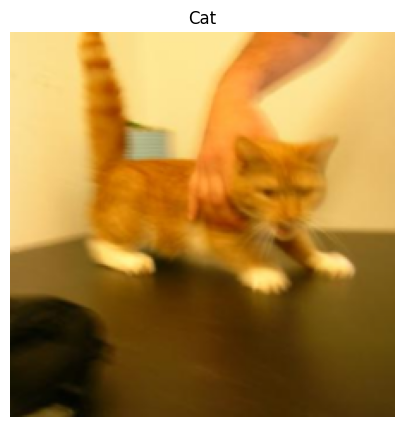

In [12]:
import matplotlib.pyplot as plt

# Get one sample
image, label = train_dataset[0]

# Undo normalization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

image = image * std + mean

# Convert CHW -> HWC
image = image.permute(1, 2, 0)

# Clip values to [0,1]
image = image.clamp(0, 1)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

In [13]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [14]:
print("Train batches :", len(train_loader))
print("Valid batches :", len(valid_loader))
print("Test batches  :", len(test_loader))

Train batches : 547
Valid batches : 118
Test batches  : 118


In [15]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("Image dtype :", images.dtype)
print("Labels dtype:", labels.dtype)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])
Image dtype : torch.float32
Labels dtype: torch.int64


In [16]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
# Number of classes in our dataset
num_classes = len(train_dataset.classes)

# Replace the final fully connected layer
model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=num_classes
)

print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [18]:
# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the final classifier
for param in model.fc.parameters():
    param.requires_grad = True

In [19]:
for name, param in model.named_parameters():
    print(f"{name:40} Trainable: {param.requires_grad}")

conv1.weight                             Trainable: False
bn1.weight                               Trainable: False
bn1.bias                                 Trainable: False
layer1.0.conv1.weight                    Trainable: False
layer1.0.bn1.weight                      Trainable: False
layer1.0.bn1.bias                        Trainable: False
layer1.0.conv2.weight                    Trainable: False
layer1.0.bn2.weight                      Trainable: False
layer1.0.bn2.bias                        Trainable: False
layer1.1.conv1.weight                    Trainable: False
layer1.1.bn1.weight                      Trainable: False
layer1.1.bn1.bias                        Trainable: False
layer1.1.conv2.weight                    Trainable: False
layer1.1.bn2.weight                      Trainable: False
layer1.1.bn2.bias                        Trainable: False
layer2.0.conv1.weight                    Trainable: False
layer2.0.bn1.weight                      Trainable: False
layer2.0.bn1.b

In [20]:
import torch
import torch.optim as optim

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (only trainable parameters)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

print("Device:", device)
print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Device: cuda
Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
NUM_EPOCHS = 5

# Store history
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 40)

    ####################################
    # Training
    ####################################
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    ####################################
    # Validation
    ####################################
    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(valid_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    ####################################
    # Save Best Model
    ####################################
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    ####################################
    # Print Results
    ####################################
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Acc:   {val_acc:.2f}%"
    )

print("\nTraining Finished!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")


Epoch [1/5]
----------------------------------------


NameError: name 'model' is not defined

In [22]:
# Load the best model
model.load_state_dict(torch.load("best_model.pth"))

# Set model to evaluation mode
model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [23]:
# Test Evaluation

model.eval()

test_loss = 0.0
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Store predictions for later evaluation
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print("=" * 50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")
print("=" * 50)

Test Loss     : 0.0525
Test Accuracy : 98.13%


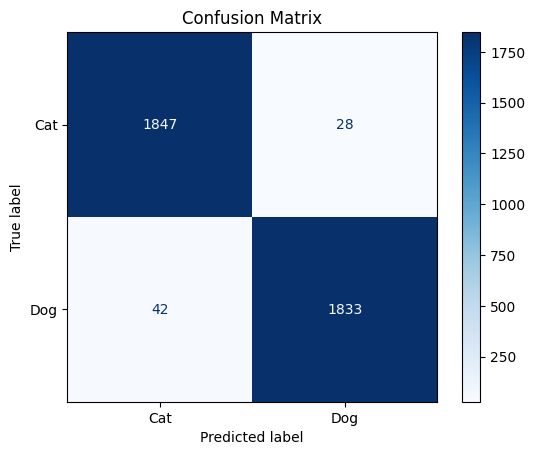

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Class names
class_names = test_dataset.classes

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [27]:
from sklearn.metrics import classification_report

# Get class names
class_names = test_dataset.classes

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

Classification Report
              precision    recall  f1-score   support

         Cat     0.9778    0.9851    0.9814      1875
         Dog     0.9850    0.9776    0.9813      1875

    accuracy                         0.9813      3750
   macro avg     0.9814    0.9813    0.9813      3750
weighted avg     0.9814    0.9813    0.9813      3750



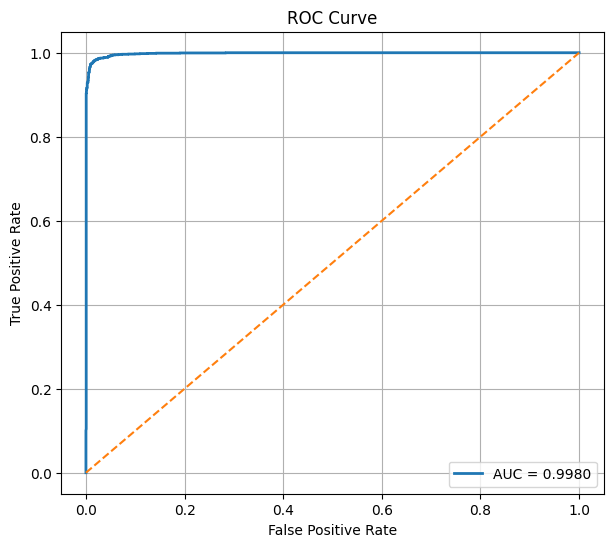

AUC Score: 0.9980


In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Put model in evaluation mode
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        # Convert logits to probabilities
        probabilities = F.softmax(outputs, dim=1)

        # Probability of the positive class (class index 1)
        all_probs.extend(probabilities[:, 1].cpu().numpy())

        all_labels.extend(labels.numpy())

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}",
    linewidth=2
)

# Random guessing line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.grid(True)

plt.show()

print(f"AUC Score: {roc_auc:.4f}")

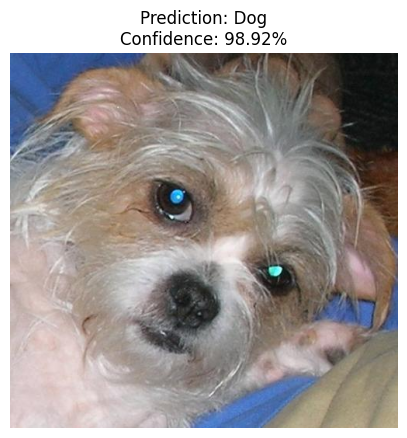

In [30]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# --------------------------------------------------
# Change this to your image path
# --------------------------------------------------
image_path = "../../../Datasets_for_my_practice/cats_vs_dogs/PetImages/Dog/10354.jpg"

# --------------------------------------------------
# Load Image
# --------------------------------------------------
image = Image.open(image_path).convert("RGB")

# Display Original Image
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")

# --------------------------------------------------
# Apply Test Transform
# --------------------------------------------------
input_tensor = valid_transform(image).unsqueeze(0).to(device)

# --------------------------------------------------
# Prediction
# --------------------------------------------------
model.eval()

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = F.softmax(outputs, dim=1)

    confidence, predicted = torch.max(probabilities, dim=1)

# --------------------------------------------------
# Class Name
# --------------------------------------------------
class_names = test_dataset.classes

predicted_class = class_names[predicted.item()]
confidence = confidence.item() * 100

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()

In [35]:
import os
from PIL import Image
import torch
import torch.nn.functional as F

# ==========================================================
# Folder containing images
# ==========================================================
folder_path = "../../../Datasets_for_my_practice/cats_vs_dogs/PetImages"

# Class names
class_names = test_dataset.classes

model.eval()

print("=" * 70)
print("Batch Prediction")
print("=" * 70)

with torch.no_grad():

    for filename in sorted(os.listdir(folder_path)):

        if filename.lower().endswith((".jpg", ".jpeg", ".png")):

            image_path = os.path.join(folder_path, filename)

            image = Image.open(image_path).convert("RGB")

            input_tensor = valid_transform(image).unsqueeze(0).to(device)

            outputs = model(input_tensor)

            probabilities = F.softmax(outputs, dim=1)

            confidence, predicted = torch.max(probabilities, dim=1)

            predicted_class = class_names[predicted.item()]
            confidence = confidence.item() * 100

            print(f"{filename:25s} -> {predicted_class:5s} ({confidence:.2f}%)")

Batch Prediction


In [36]:
import torch

MODEL_PATH = "cats_vs_dogs_resnet18.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("=" * 60)
print("Model Saved Successfully!")
print(f"Saved as: {MODEL_PATH}")
print("=" * 60)

Model Saved Successfully!
Saved as: cats_vs_dogs_resnet18.pth


In [37]:
import torch
from torchvision.models import resnet18

# Create same architecture
loaded_model = resnet18(weights=None)

# Replace final layer
loaded_model.fc = torch.nn.Linear(
    loaded_model.fc.in_features,
    len(test_dataset.classes)
)

# Load weights
loaded_model.load_state_dict(torch.load("cats_vs_dogs_resnet18.pth", map_location=device))

loaded_model.to(device)
loaded_model.eval()

print("=" * 60)
print("Saved model loaded successfully!")
print("=" * 60)

Saved model loaded successfully!


In [38]:
print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print(f"Model                : ResNet18 (Transfer Learning)")
print(f"Dataset              : Cats vs Dogs")
print(f"Number of Classes    : {len(test_dataset.classes)}")
print(f"Classes              : {test_dataset.classes}")

print("-" * 70)

print(f"Best Validation Accuracy : {best_val_acc:.2f}%")
print(f"Test Accuracy            : {test_accuracy:.2f}%")
print(f"Test Loss                : {test_loss:.4f}")
print(f"AUC Score                : {roc_auc:.4f}")

print("-" * 70)

print("Training Completed Successfully!")
print("Model Saved Successfully!")
print("Ready for Inference / Deployment!")

print("=" * 70)

FINAL PROJECT SUMMARY
Model                : ResNet18 (Transfer Learning)
Dataset              : Cats vs Dogs
Number of Classes    : 2
Classes              : ['Cat', 'Dog']
----------------------------------------------------------------------
Best Validation Accuracy : 98.13%
Test Accuracy            : 98.13%
Test Loss                : 0.0525
AUC Score                : 0.9980
----------------------------------------------------------------------
Training Completed Successfully!
Model Saved Successfully!
Ready for Inference / Deployment!
